# HCMUT-P4AIDS ASSIGNMENT 1 - EDA

## Tabular dataset: "younusmohamed/bank-telemarketing"



In [56]:
# Install dependencies
import pandas as pd
import kagglehub as KD
from kagglehub import KaggleDatasetAdapter as KDA
import seaborn as sns
import matplotlib.pyplot as plt
# import plotly.express as px
# import plotly.graph_objects as go
# from plotly.subplots import make_subplots

In [57]:
file_path = "Banking_Call_Data.xlsx"
df = KD.dataset_load(
  KDA.PANDAS,
  "younusmohamed/bank-telemarketing",
  file_path
)

In [58]:
df.info()
df.head(10)

<class 'pandas.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   age        45211 non-null  int64
 1   job        45211 non-null  str  
 2   marital    45211 non-null  str  
 3   education  45211 non-null  str  
 4   default    45211 non-null  str  
 5   balance    45211 non-null  int64
 6   housing    45211 non-null  str  
 7   loan       45211 non-null  str  
 8   contact    45211 non-null  str  
 9   day        45211 non-null  int64
 10  month      45211 non-null  str  
 11  duration   45211 non-null  int64
 12  campaign   45211 non-null  int64
 13  pdays      45211 non-null  int64
 14  previous   45211 non-null  int64
 15  poutcome   45211 non-null  str  
 16  y          45211 non-null  str  
dtypes: int64(7), str(10)
memory usage: 5.9 MB


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,-1,0,unknown,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,-1,0,unknown,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,-1,0,unknown,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,-1,0,unknown,no


In [59]:
# df.isna().sum()
# df.duplicated().sum()

In [60]:
# print(df.dtypes)
# df.describe()

In [61]:
# Get numerical attributes list (no binary)
num_attrs= ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
bin_attrs= ['default', 'housing', 'loan', 'y']
print(num_attrs)
print(f'Number of numerical attributes: {len(num_attrs)}')
print(f'Feature Statistics:')
for attr in num_attrs:
    print(f'{attr}:')
    print(f'Mean: {df[attr].mean()}')
    print(f'Median: {df[attr].median()}')
    print(f'Std: {df[attr].std()}')




['age', 'balance', 'duration', 'campaign', 'pdays', 'previous']
Number of numerical attributes: 6
Feature Statistics:
age:
Mean: 40.93621021432837
Median: 39.0
Std: 10.61876204097542
balance:
Mean: 1362.2720576850766
Median: 448.0
Std: 3044.7658291685175
duration:
Mean: 258.1630797814691
Median: 180.0
Std: 257.5278122651719
campaign:
Mean: 2.763840658246887
Median: 2.0
Std: 3.0980208832791694
pdays:
Mean: 40.19782796222158
Median: -1.0
Std: 100.12874599059835
previous:
Mean: 0.5803233726305546
Median: 0.0
Std: 2.3034410449312213


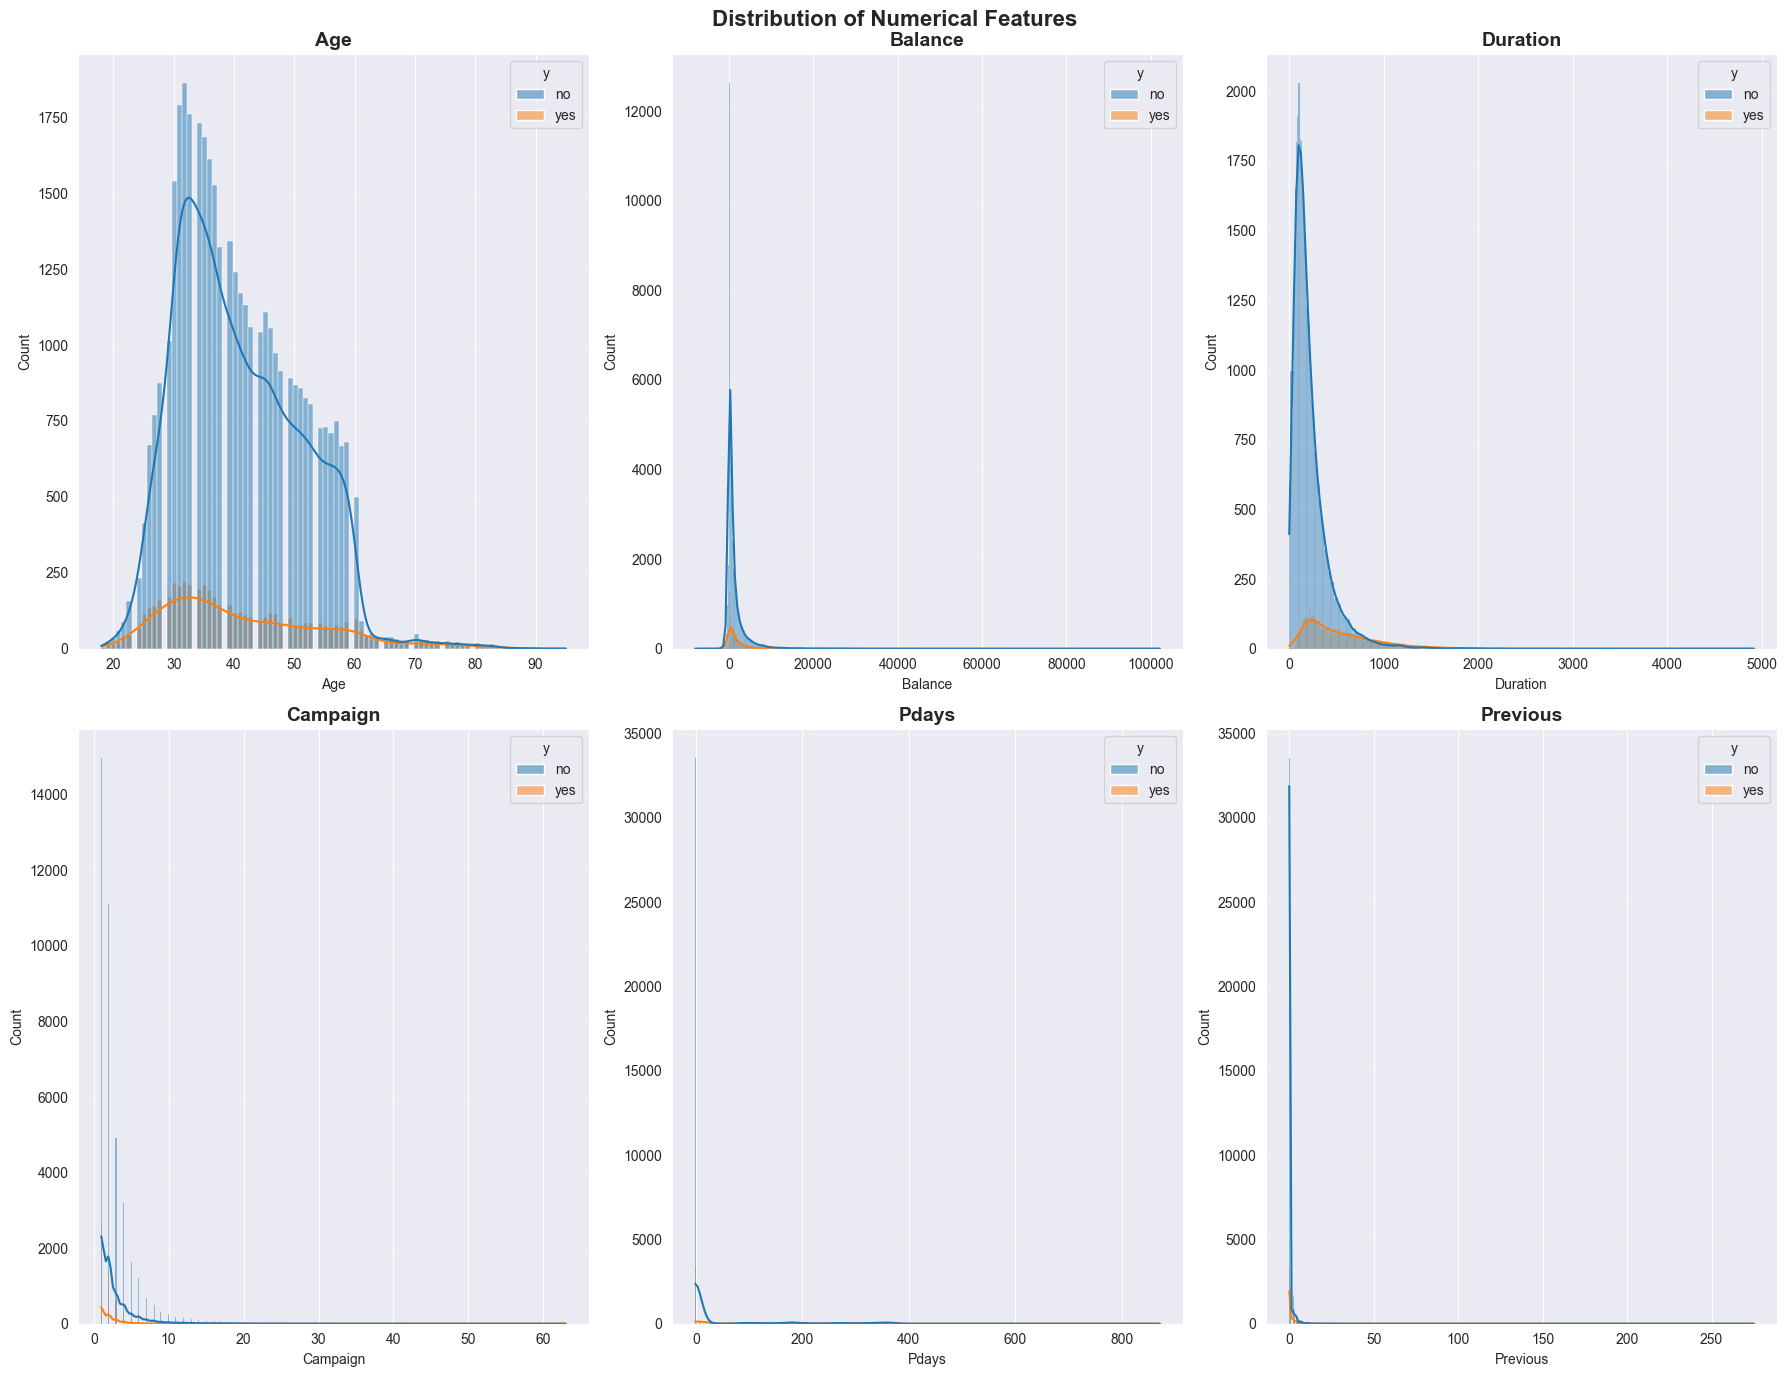

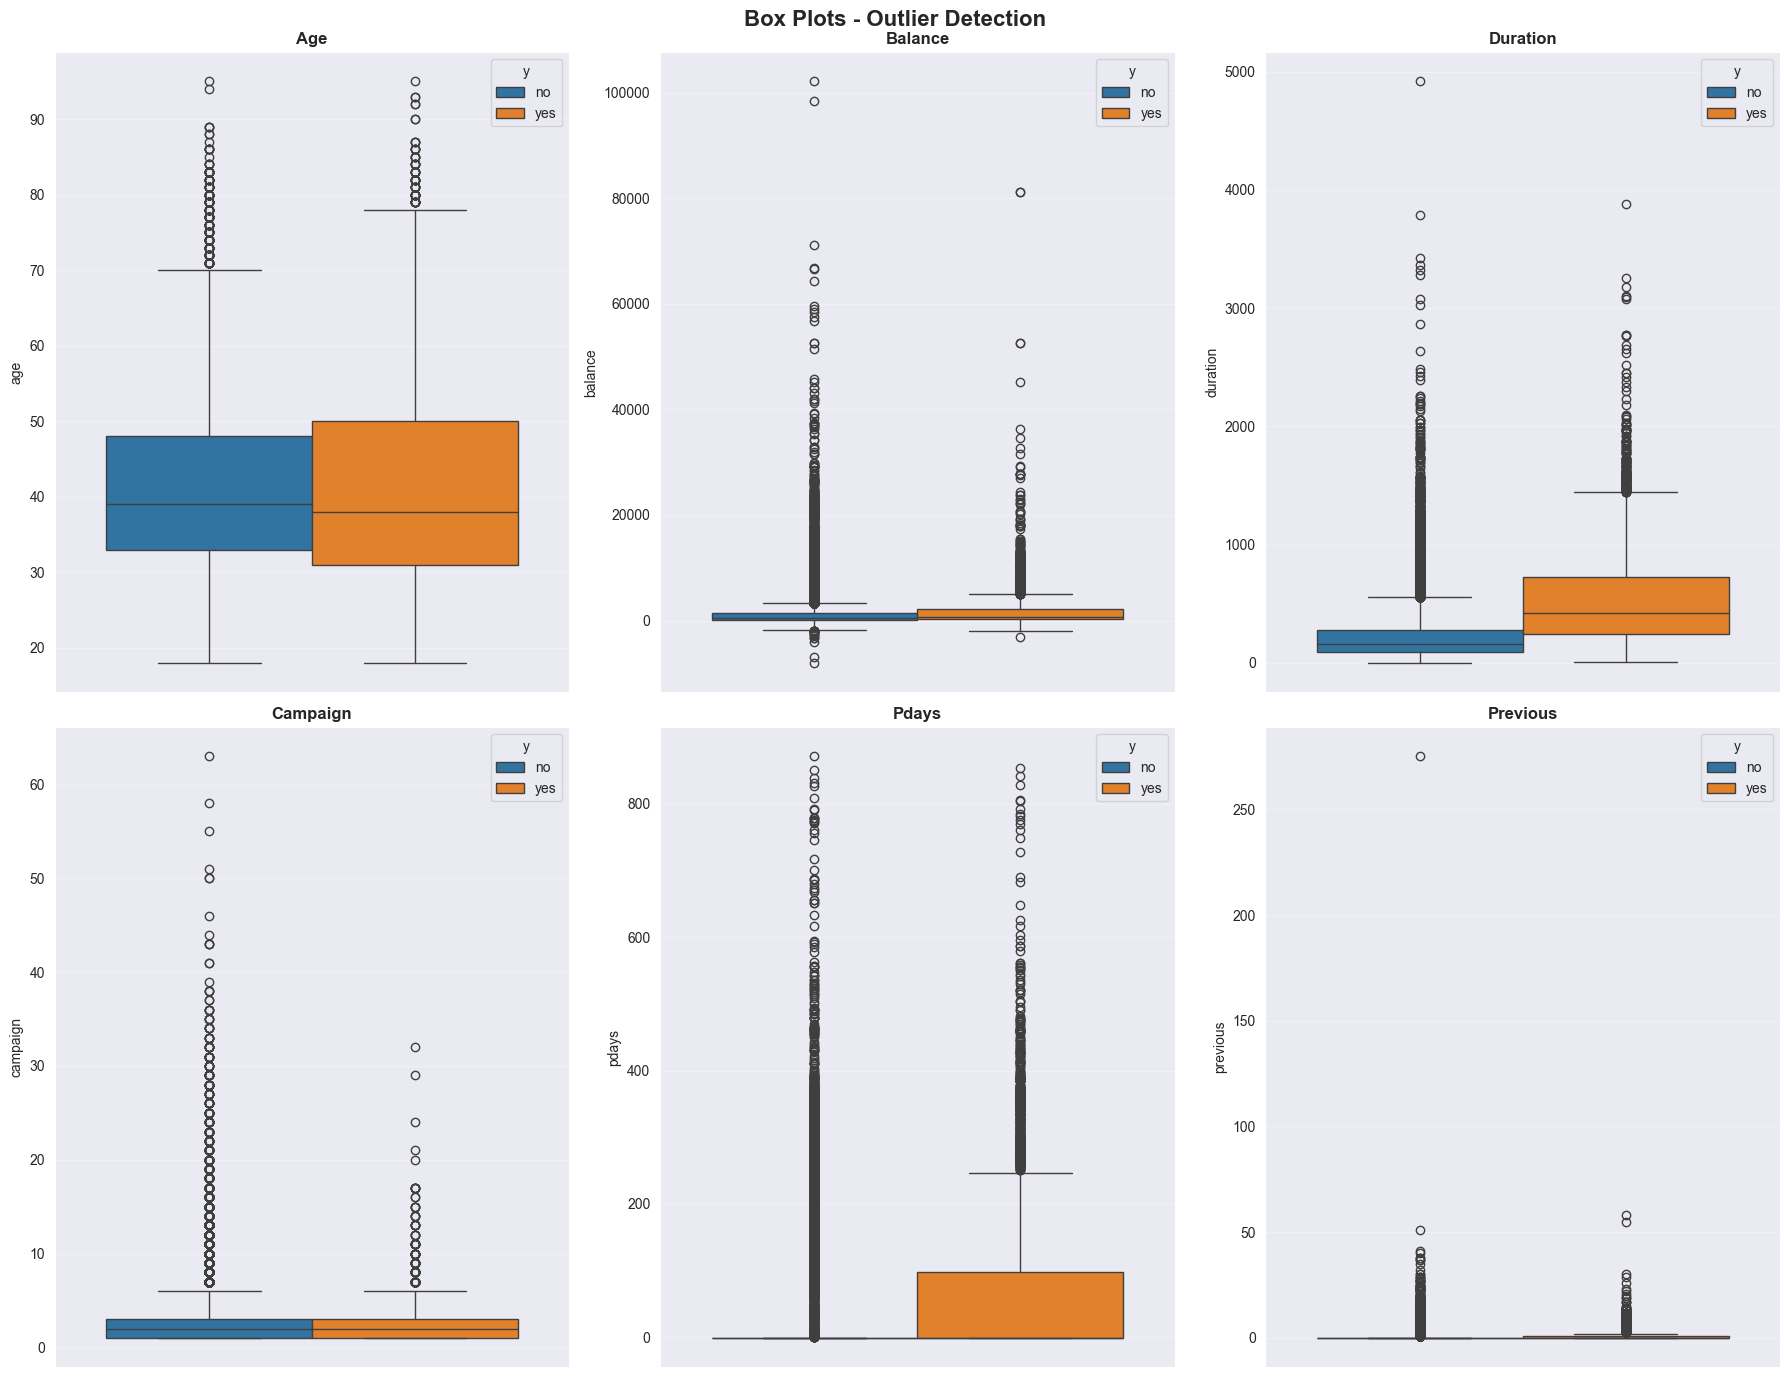

In [62]:
# Subplot division
sp_col = 3
sp_row = len(num_attrs) // sp_col + (len(num_attrs) % sp_col > 0)
fig, axes = plt.subplots(nrows=sp_row, ncols=sp_col, figsize=(18, 14))
axes = axes.flatten()
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')
for (idx, col) in enumerate(num_attrs):
    ax = axes[idx]
    sns.histplot(data=df, x= col, kde= True, ax=ax, hue= df['y'])
    ax.set_title(col.replace('_', ' ').title(), fontsize=14, fontweight='bold')
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.grid(axis='y', alpha=0.3)
for j in range(len(num_attrs), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()

#Box plots for outlier detection
fig, axes = plt.subplots(nrows=sp_row, ncols=sp_col, figsize=(18, 14))
axes = axes.flatten()  # <-- flatten the 2D array
fig.suptitle('Box Plots - Outlier Detection', fontsize=16, fontweight='bold')

for idx, col in enumerate(num_attrs):
    ax = axes[idx]
    sns.boxplot(y=df[col], ax=ax, hue= df['y'])
    ax.set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.grid(axis='y', alpha=0.3)
for j in range(len(num_attrs), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


default:
default
no     44396
yes      815
Name: count, dtype: int64
housing:
housing
yes    25130
no     20081
Name: count, dtype: int64
loan:
loan
no     37967
yes     7244
Name: count, dtype: int64
y:
y
no     39922
yes     5289
Name: count, dtype: int64


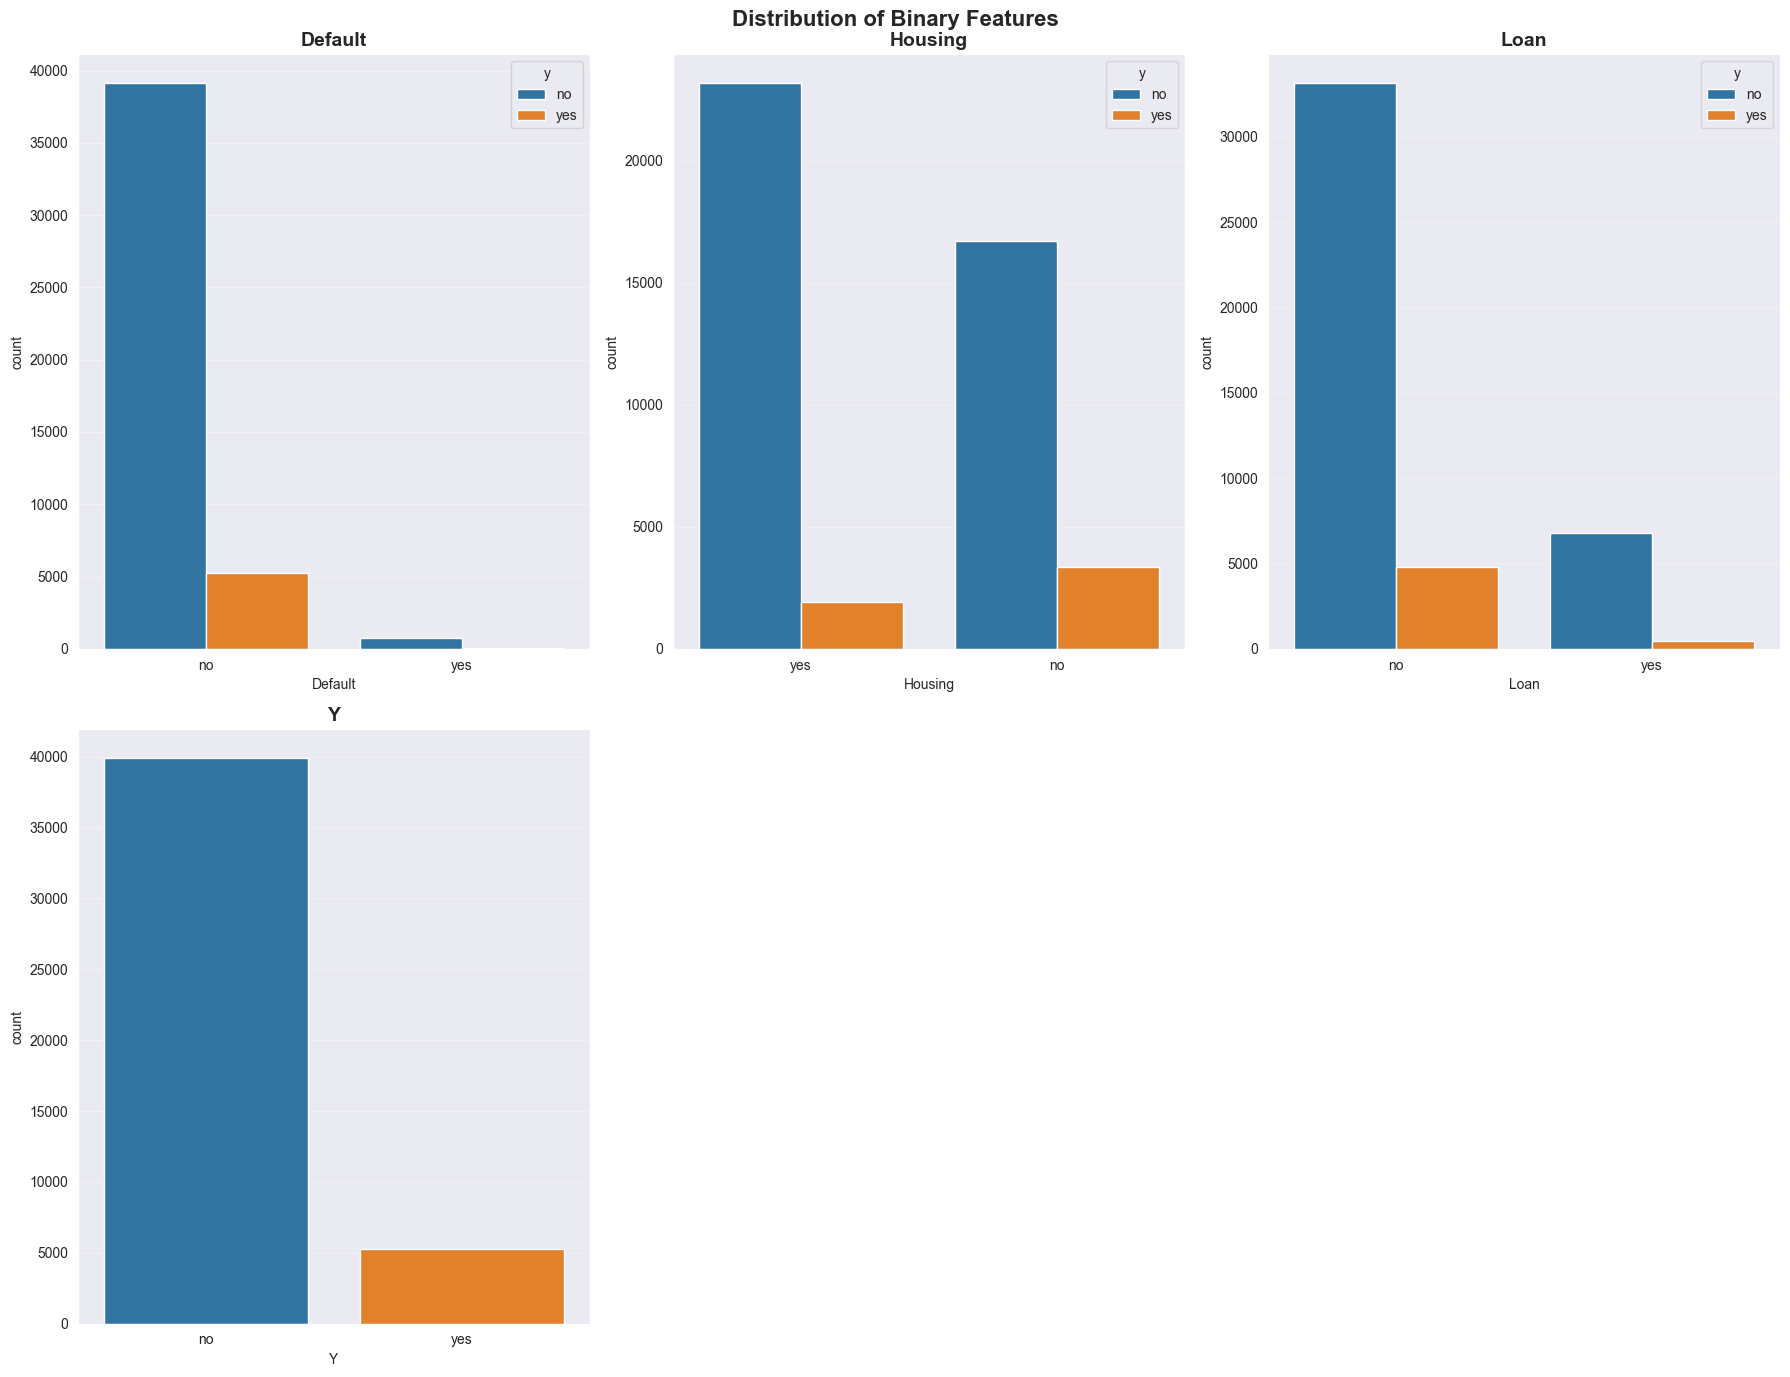

In [63]:
#binary attribute
for attr in bin_attrs:
    print(f'{attr}:')
    print(df[attr].value_counts())
sp_col = 3
sp_row = len(num_attrs) // sp_col + (len(num_attrs) % sp_col > 0)
fig, axes = plt.subplots(nrows=sp_row, ncols=sp_col, figsize=(18, 14))
axes = axes.flatten()
fig.suptitle('Distribution of Binary Features', fontsize=16, fontweight='bold')
for (idx, col) in enumerate(bin_attrs):
    ax = axes[idx]
    sns.countplot(data=df, x= col, ax=ax, hue= df['y'])
    ax.set_title(col.replace('_', ' ').title(), fontsize=14, fontweight='bold')
    ax.set_xlabel(col.replace('_', ' ').title())
    ax.grid(axis='y', alpha=0.3)
for j in range(len(bin_attrs), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()
plt.show()



In [64]:
#Categorical attributes
cat_attrs= ['job', 'marital', 'education', 'contact', 'month', 'poutcome']
print(cat_attrs)

['job', 'marital', 'education', 'contact', 'month', 'poutcome']


Value Counts for Categorical Features:
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64
marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64
contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64
month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Name: count, dtype: int64
poutcome
unknown    36959
failure     4901
other       1840
success     1511
Name: count, dtype: int64


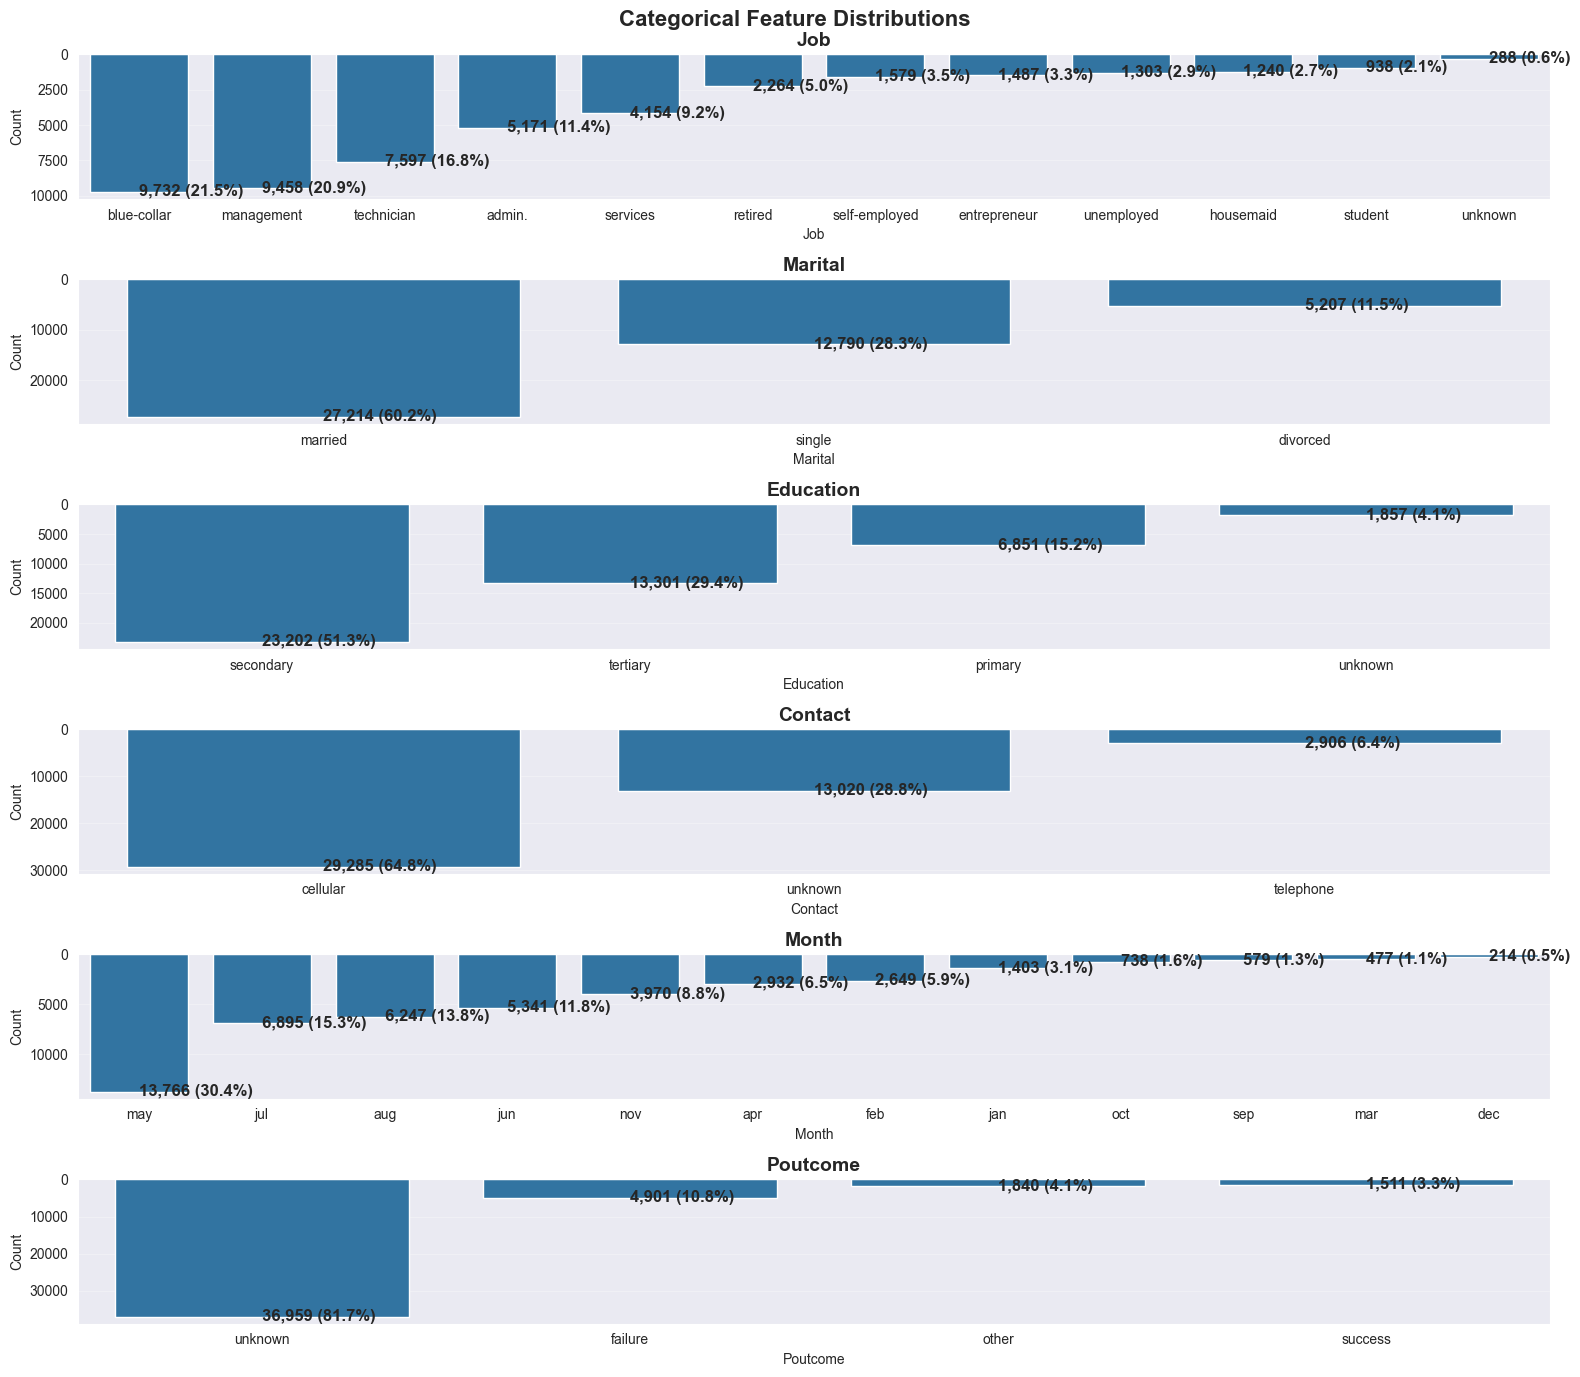

In [78]:
#get value counts for categorical attributes
print('Value Counts for Categorical Features:')
val_counts = [df[attr].value_counts() for attr in cat_attrs]
for i, attr in enumerate(cat_attrs):
    print(val_counts[i])
#plot value counts for categorical attributes
fig, axes = plt.subplots(nrows=len(cat_attrs), ncols=1, figsize=(16, 14))
axes = axes.flatten()
fig.suptitle('Categorical Feature Distributions', fontsize=16, fontweight='bold')
for i, attr in enumerate(cat_attrs):
    ax = axes[i]
    sns.barplot(x=val_counts[i].index, y=val_counts[i].values, ax=ax)
    ax.set_title(attr.replace('_', ' ').title(), fontsize=14, fontweight='bold')
    ax.set_xlabel(attr.replace('_', ' ').title())
    ax.set_ylabel('Count')
    ax.invert_yaxis()
    ax.grid(axis='y', alpha=0.3)
    total = val_counts[i].sum()
    for x,y in enumerate(val_counts[i].values):
         ax.text(x, y+0.05, f'{y:,} ({y/total*100:.1f}%)',va='center', fontsize=12, fontweight='bold')
for j in range(len(cat_attrs), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()


